# do-Shapley: Causal Contributions via do-interventions

This notebook demonstrates the `DoCausalImputer` which implements causal Shapley values based on the paper:

> **"On Measuring Causal Contributions via do-interventions"** (Jung, Tian, & Bareinboim, ICML 2022)

## Key Concepts

### Standard SHAP vs Causal SHAP (Heskes) vs do-Shapley

| Method | Value Function | Handles Confounding | Input |
|--------|---------------|---------------------|-------|
| Standard SHAP (MSV) | $\mathbb{E}[Y \mid X_S = x_S]$ (conditional) | ❌ No | None |
| Causal SHAP (CSV) | Conditional with causal ordering | ⚠️ Partial | Ordering + Confounding |
| **do-Shapley** | $\mathbb{E}[Y \mid do(X_S = x_S)]$ (interventional) | ✅ Yes | DAG (edges) |

### do-intervention

The `do(X=x)` operator:
- **Cuts** all incoming edges to X in the causal graph
- **Sets** X to value x
- Removes spurious correlations through confounders

## Dataset: Bike Sharing Daily

We use the UCI Bike Sharing Dataset (**daily** aggregates, 731 samples) with the same preprocessing as Heskes et al. (2020), enabling direct comparison with Causal SHAP.

## Reference
- do-Shapley: https://proceedings.mlr.press/v162/jung22a.html
- Causal SHAP (Heskes): https://arxiv.org/abs/2011.01625

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import xgboost as xgb

import shapiq
from shapiq import TabularExplainer
from shapiq.imputer import DoCausalImputer, MarginalImputer, CausalImputer
from shapiq.datasets import load_bike_sharing_daily, load_bike_sharing_daily_train_index

print(f"shapiq version: {shapiq.__version__}")

e:\Desktop\Shapley\Shapiq\shapiq\.venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


shapiq version: None


## 1. Load Bike Sharing Daily Data

The dataset uses the UCI Bike Sharing Dataset (**daily** aggregates) with specific preprocessing from Heskes et al. (2020):

- **trend**: Days since January 1, 2011
- **cosyear**: cos(2π × trend / 365) - cyclical season
- **sinyear**: sin(2π × trend / 365) - cyclical season
- **temp**: Unnormalized temperature (°C)
- **atemp**: Unnormalized feeling temperature (°C)
- **windspeed**: Unnormalized wind speed
- **hum**: Unnormalized humidity (%)

In [2]:
# Load preprocessed data from shapiq.datasets (same as Heskes paper reproduction)
x_data, y_data = load_bike_sharing_daily(preprocessed=True)
train_idx = load_bike_sharing_daily_train_index()

feature_names = ["trend", "cosyear", "sinyear", "temp", "atemp", "windspeed", "hum"]
n_features = len(feature_names)

# Create train/test split (same as Heskes paper)
all_idx = np.arange(len(x_data))
test_idx = np.array([i for i in all_idx if i not in train_idx])

print(f"Total samples: {len(x_data)} (UCI Bike Sharing Daily)")
print(f"Training samples: {len(train_idx)}")
print(f"Test samples: {len(test_idx)}")
print(f"Features ({n_features}): {feature_names}")

Total samples: 731 (UCI Bike Sharing Daily)
Training samples: 587
Test samples: 144
Features (7): ['trend', 'cosyear', 'sinyear', 'temp', 'atemp', 'windspeed', 'hum']


In [3]:
# Prepare data with centering (as in original Heskes paper)
X_train = x_data.iloc[train_idx].values
y_train_nc = y_data.iloc[train_idx].values  # not centered
y_train_mean = y_train_nc.mean()
y_train = y_train_nc - y_train_mean  # centered

X_test = x_data.iloc[test_idx].values
y_test = y_data.iloc[test_idx].values - y_train_mean  # centered using train mean

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train mean (φ₀): {y_train_mean:.2f}")

X_train shape: (587, 7)
X_test shape: (144, 7)
y_train mean (φ₀): 4505.03


### 1.1. Data Visualization: Bike Rentals Over Time

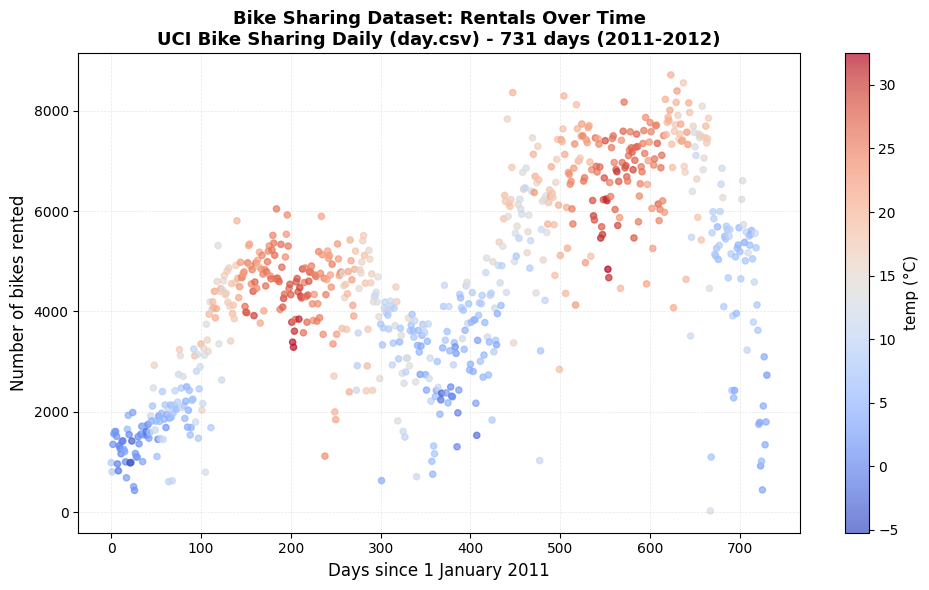


Data Patterns Observed:
1. TREND: Bike rentals generally increase over time (2011-2012)
2. SEASONALITY: Clear seasonal pattern with peaks in warm months
3. TEMPERATURE: Warmer days (red) tend to have more rentals
4. The correlation between temp and rentals is confounded by season


In [4]:
# Visualize: Number of bikes rented over time, colored by temperature
fig, ax = plt.subplots(figsize=(10, 6))

# Use full dataset for visualization (not centered)
trend_values = x_data['trend'].values
temp_values = x_data['temp'].values
y_values = y_data.values  # Original bike rental counts

# Create scatter plot
scatter = ax.scatter(trend_values, y_values, c=temp_values, 
                     cmap='coolwarm', s=20, alpha=0.7)

ax.set_xlabel('Days since 1 January 2011', fontsize=12)
ax.set_ylabel('Number of bikes rented', fontsize=12)
ax.set_title('Bike Sharing Dataset: Rentals Over Time\n'
             'UCI Bike Sharing Daily (day.csv) - 731 days (2011-2012)', 
             fontsize=13, fontweight='bold')

# Add colorbar
cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('temp (°C)', fontsize=11)

# Add grid for better readability
ax.grid(True, alpha=0.3, linestyle='--', linewidth=0.5)

plt.tight_layout()
plt.show()

print("\nData Patterns Observed:")
print("=" * 60)
print("1. TREND: Bike rentals generally increase over time (2011-2012)")
print("2. SEASONALITY: Clear seasonal pattern with peaks in warm months")
print("3. TEMPERATURE: Warmer days (red) tend to have more rentals")
print("4. The correlation between temp and rentals is confounded by season")
print("=" * 60)

## 2. Train XGBoost Model

In [5]:
# Train XGBoost model (same as Heskes paper)
model = xgb.XGBRegressor(
    n_estimators=100,
    random_state=1,
    verbosity=0
)
model.fit(X_train, y_train)

# Evaluate
y_pred = model.predict(X_test)
rmse = np.sqrt(np.mean((y_test - y_pred) ** 2))
print(f"Test RMSE (centered): {rmse:.2f}")

Test RMSE (centered): 775.24


## 3. Define Causal DAG Structure

### Causal Structure from Heskes et al. (2020)

The paper uses a layered causal ordering:
- **Layer 1 (Root cause)**: `{trend}`
- **Layer 2 (Confounded)**: `{cosyear, sinyear}` - season affects weather
- **Layer 3 (Mutual interactions)**: `{temp, atemp, windspeed, hum}`

### do-Shapley DAG Edges

For `DoCausalImputer`, we specify causal edges directly:
```
trend → cosyear, sinyear
trend → temp, atemp, windspeed, hum
cosyear, sinyear → temp, atemp, windspeed, hum
```

Additionally, we specify confounding pairs for Layer 3 variables.

In [6]:
# Feature indices:
# 0: trend, 1: cosyear, 2: sinyear, 3: temp, 4: atemp, 5: windspeed, 6: hum

# Define DAG edges based on causal structure from Heskes paper
dag_edges = [
    # Layer 1 → Layer 2: trend causes season
    (0, 1), (0, 2),  # trend → cosyear, sinyear
    
    # Layer 1 → Layer 3: trend causes weather
    (0, 3), (0, 4), (0, 5), (0, 6),  # trend → temp, atemp, windspeed, hum
    
    # Layer 2 → Layer 3: season causes weather
    (1, 3), (1, 4), (1, 5), (1, 6),  # cosyear → temp, atemp, windspeed, hum
    (2, 3), (2, 4), (2, 5), (2, 6),  # sinyear → temp, atemp, windspeed, hum
]

# Confounding pairs (variables that share hidden common causes)
# Layer 3 variables have mutual dependencies (weather system)
confounding_pairs = {
    (3, 4),  # temp <-> atemp
    (3, 5),  # temp <-> windspeed
    (3, 6),  # temp <-> hum
    (4, 5),  # atemp <-> windspeed
    (4, 6),  # atemp <-> hum
    (5, 6),  # windspeed <-> hum
    (1, 2),  # cosyear <-> sinyear (confounded in Layer 2)
}

# Also define ordering for CausalImputer comparison
ordering = [
    [0],           # Layer 1: trend (root)
    [1, 2],        # Layer 2: cosyear, sinyear (confounded)
    [3, 4, 5, 6],  # Layer 3: temp, atemp, windspeed, hum
]
confounding_layers = [False, True, False]

print("Causal Structure:")
print("=" * 60)
print("DAG Edges:")
for p, c in dag_edges:
    print(f"  {feature_names[p]} → {feature_names[c]}")
print(f"\nConfounding pairs: {[(feature_names[i], feature_names[j]) for i, j in confounding_pairs]}")
print("\nOrdering (for CausalImputer comparison):")
for i, layer in enumerate(ordering):
    layer_names = [feature_names[j] for j in layer]
    print(f"  Layer {i+1}: {layer_names} (confounding={confounding_layers[i]})")

Causal Structure:
DAG Edges:
  trend → cosyear
  trend → sinyear
  trend → temp
  trend → atemp
  trend → windspeed
  trend → hum
  cosyear → temp
  cosyear → atemp
  cosyear → windspeed
  cosyear → hum
  sinyear → temp
  sinyear → atemp
  sinyear → windspeed
  sinyear → hum

Confounding pairs: [('atemp', 'windspeed'), ('cosyear', 'sinyear'), ('temp', 'atemp'), ('windspeed', 'hum'), ('temp', 'hum'), ('atemp', 'hum'), ('temp', 'windspeed')]

Ordering (for CausalImputer comparison):
  Layer 1: ['trend'] (confounding=False)
  Layer 2: ['cosyear', 'sinyear'] (confounding=True)
  Layer 3: ['temp', 'atemp', 'windspeed', 'hum'] (confounding=False)


## 4. Create Explainers

We create 4 explainers:
1. **Marginal (Joint)** - Standard SHAP (MSV from Heskes paper)
2. **Causal+Model (Gaussian)** - CausalImputer (CSV from Heskes paper) ★
3. **do-Shapley (DML)** - DoCausalImputer with Double Machine Learning
4. **do-Shapley (REG)** - DoCausalImputer with Regression/Plug-in

In [7]:
# Configuration
RANDOM_STATE = 42
SAMPLE_SIZE = 1000

explainers = {}

# =============================================================================
# 1. MARGINAL SHAP (MSV - Paper baseline)
# =============================================================================
explainers['Marginal (Joint)'] = TabularExplainer(
    model=model.predict,
    data=X_train,
    imputer="marginal",
    index="k-SII",
    max_order=2,
    random_state=RANDOM_STATE
)

# =============================================================================
# 2. CAUSAL SHAP (CSV - Heskes et al. 2020) ★
# =============================================================================
causal_gaussian_imputer = CausalImputer(
    model=model.predict,
    data=X_train,
    ordering=ordering,
    confounding=confounding_layers,
    sampling_method="gaussian",
    sample_size=SAMPLE_SIZE,
    random_state=RANDOM_STATE
)
explainers['Causal+Model (Gaussian)'] = TabularExplainer(
    model=model.predict,
    data=X_train,
    imputer=causal_gaussian_imputer,
    index="k-SII",
    max_order=2,
    random_state=RANDOM_STATE
)

# =============================================================================
# 3. do-SHAPLEY (DML) - Double Machine Learning
# =============================================================================
do_imputer_dml = DoCausalImputer(
    model=model.predict,
    data=X_train,
    dag_edges=dag_edges,
    confounding_pairs=confounding_pairs,
    method="dml",
    random_state=RANDOM_STATE
)
explainers['do-Shapley (DML)'] = TabularExplainer(
    model=model.predict,
    data=X_train,
    imputer=do_imputer_dml,
    index="k-SII",
    max_order=2,
    random_state=RANDOM_STATE
)

# =============================================================================
# 4. do-SHAPLEY (REG) - Regression/Plug-in
# =============================================================================
do_imputer_reg = DoCausalImputer(
    model=model.predict,
    data=X_train,
    dag_edges=dag_edges,
    confounding_pairs=confounding_pairs,
    method="reg",
    random_state=RANDOM_STATE
)
explainers['do-Shapley (REG)'] = TabularExplainer(
    model=model.predict,
    data=X_train,
    imputer=do_imputer_reg,
    index="k-SII",
    max_order=2,
    random_state=RANDOM_STATE
)

print("All explainers created with k-SII (max_order=2)!")
print("\nMethods:")
for name in explainers:
    marker = " ★[Paper CSV]" if name == 'Causal+Model (Gaussian)' else ""
    marker = " [Paper MSV]" if name == 'Marginal (Joint)' else marker
    print(f"  - {name}{marker}")

All explainers created with k-SII (max_order=2)!

Methods:
  - Marginal (Joint) [Paper MSV]
  - Causal+Model (Gaussian) ★[Paper CSV]
  - do-Shapley (DML)
  - do-Shapley (REG)


## 5. Compute Shapley Values for All Test Samples

> **Note**: This step computes k-Shapley Interaction Index (k-SII, max_order=2) for all 4 methods across all test samples. Expected runtime: **20-40 minutes** depending on your hardware.

In [ ]:
budget = 2048

# Store all k-SII results (InteractionValues objects) and extracted 1st-order values
all_ksii = {}  # Full InteractionValues for each sample
all_sv = {}    # 1st-order values only (for backward compatibility with existing plots)

for exp_name, explainer in explainers.items():
    print(f"\nComputing k-SII (max_order=2) for {exp_name} across {len(X_test)} samples...")
    ksii_list = []  # Store full InteractionValues for each sample
    sv = np.zeros((len(X_test), n_features))
    
    for i in range(len(X_test)):
        result = explainer.explain(X_test[i:i+1], budget=budget)
        ksii_list.append(result)  # Store full result with interactions
        sv[i] = result.get_n_order_values(order=1)  # Extract 1st-order for backward compat
        if (i + 1) % 50 == 0:
            print(f"  Processed {i + 1}/{len(X_test)}")
    
    all_ksii[exp_name] = ksii_list
    all_sv[exp_name] = sv
    print(f"  Done!")

print("\n" + "="*50)
print("All k-SII values (1st & 2nd order) computed!")
print("="*50)


Computing k-SII values for Marginal SHAP...
  Done! (15 samples)

Computing k-SII values for do-Shapley (DML)...


KeyboardInterrupt: 

## 6. Scatter Plots: 2×2 Grid Comparison (Figure 3 Style)

Following Heskes et al. (2020) Figure 3, we compare:
- **MSV**: Marginal (Joint) - standard marginal SHAP
- **CSV**: Causal+Model (Gaussian) - the method proposed in Heskes paper
- **do-Shapley**: DML and REG variants

The key comparison is between `temp` and `cosyear` attributions.

C:\Users\bodun\AppData\Local\Temp\ipykernel_20188\673955167.py:47: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.88, 0.92])


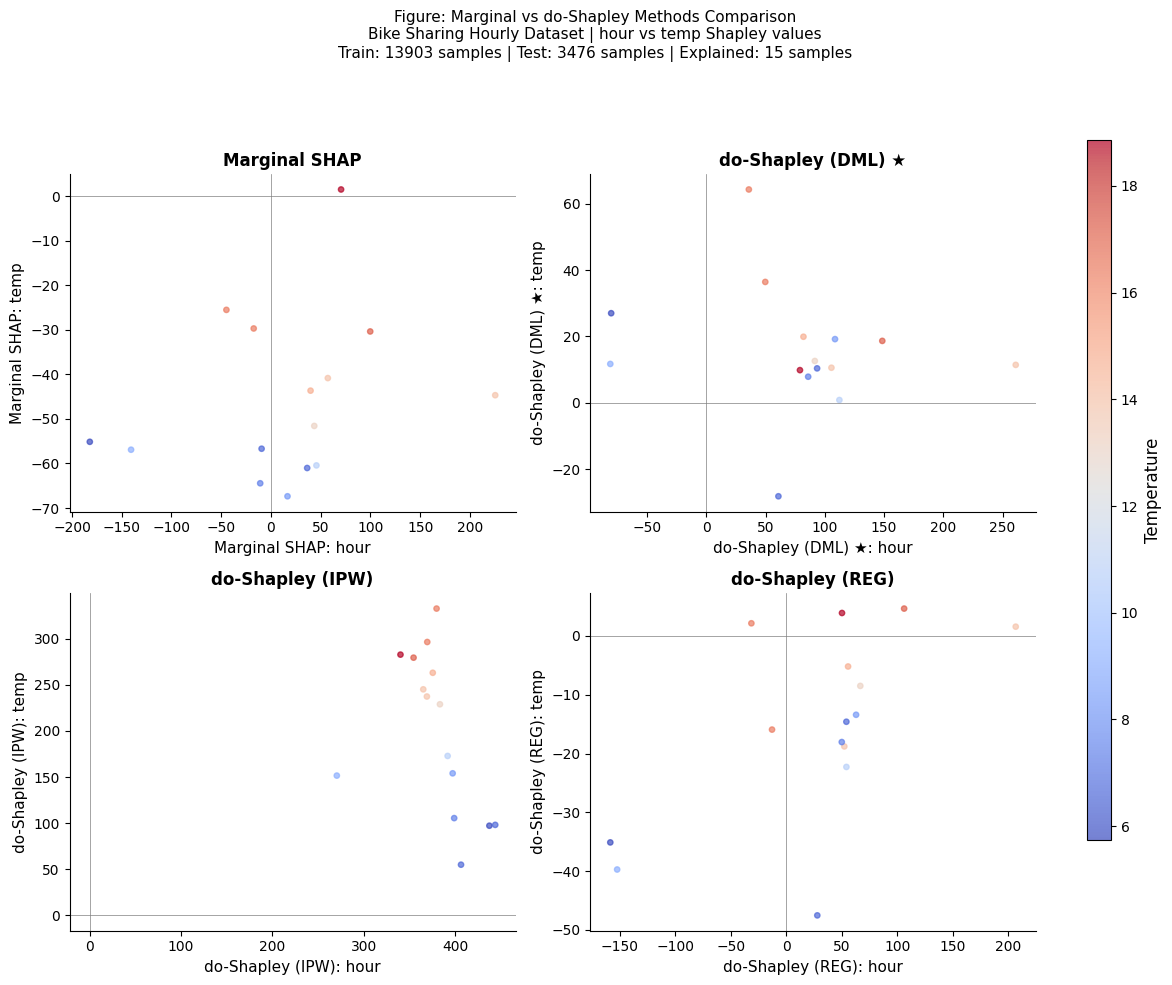

In [ ]:
# Get feature indices for visualization (matching Heskes paper)
temp_idx = feature_names.index('temp')
cosyear_idx = feature_names.index('cosyear')

# Extract Shapley values
sv_marginal = all_sv['Marginal (Joint)']
sv_causal = all_sv['Causal+Model (Gaussian)']
sv_dml = all_sv['do-Shapley (DML)']
sv_reg = all_sv['do-Shapley (REG)']

# Temperature values for coloring
temp_values = X_test[:, temp_idx]

# Create 2x2 figure matching Heskes paper Figure 3 layout
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
cmap = 'coolwarm'
point_size = 15

# Top left: MSV temp (x) vs MSV cosyear (y)
ax = axes[0, 0]
scatter = ax.scatter(sv_marginal[:, temp_idx], sv_marginal[:, cosyear_idx], 
                    c=temp_values, cmap=cmap, s=point_size, alpha=0.7)
ax.set_xlabel('MSV temp', fontsize=12)
ax.set_ylabel('MSV cosyear', fontsize=12)
ax.axhline(y=0, color='gray', linewidth=0.5)
ax.axvline(x=0, color='gray', linewidth=0.5)
ax.set_title('Marginal (Joint) [Paper MSV]', fontsize=11, fontweight='bold')

# Top right: CSV cosyear (x) vs MSV cosyear (y)
ax = axes[0, 1]
ax.scatter(sv_causal[:, cosyear_idx], sv_marginal[:, cosyear_idx], 
          c=temp_values, cmap=cmap, s=point_size, alpha=0.7)
ax.set_xlabel('CSV cosyear', fontsize=12)
ax.set_ylabel('MSV cosyear', fontsize=12)
ax.axhline(y=0, color='gray', linewidth=0.5)
ax.axvline(x=0, color='gray', linewidth=0.5)
ax.set_title('Causal (Gaussian) ★[Paper CSV]', fontsize=11, fontweight='bold')

# Bottom left: do-Shapley (DML) temp vs cosyear
ax = axes[1, 0]
ax.scatter(sv_dml[:, temp_idx], sv_dml[:, cosyear_idx],
          c=temp_values, cmap=cmap, s=point_size, alpha=0.7)
ax.set_xlabel('do-Shapley temp', fontsize=12)
ax.set_ylabel('do-Shapley cosyear', fontsize=12)
ax.axhline(y=0, color='gray', linewidth=0.5)
ax.axvline(x=0, color='gray', linewidth=0.5)
ax.set_title('do-Shapley (DML)', fontsize=11, fontweight='bold')

# Bottom right: do-Shapley (REG) temp vs cosyear
ax = axes[1, 1]
scatter = ax.scatter(sv_reg[:, temp_idx], sv_reg[:, cosyear_idx],
                    c=temp_values, cmap=cmap, s=point_size, alpha=0.7)
ax.set_xlabel('do-Shapley temp', fontsize=12)
ax.set_ylabel('do-Shapley cosyear', fontsize=12)
ax.axhline(y=0, color='gray', linewidth=0.5)
ax.axvline(x=0, color='gray', linewidth=0.5)
ax.set_title('do-Shapley (REG)', fontsize=11, fontweight='bold')

# Add colorbar
fig.subplots_adjust(right=0.88)
cbar_ax = fig.add_axes([0.91, 0.15, 0.02, 0.7])
cbar = fig.colorbar(scatter, cax=cbar_ax)
cbar.set_label('Temperature (°C)', fontsize=12)

plt.suptitle('Figure: Marginal vs Causal vs do-Shapley Comparison\n'
             'Bike Sharing Daily Dataset | temp vs cosyear Shapley values\n'
             f'Train: {len(train_idx)} samples | Test: {len(test_idx)} samples', fontsize=11)
plt.tight_layout(rect=[0, 0, 0.88, 0.92])
plt.show()

### 6.1. Interpretation

**Marginal Shapley Values (MSV)**:
- `temp` shows strong positive/negative contributions
- `cosyear` shows weaker contributions
- Points form a linear pattern due to correlation between temp and season

**Causal Shapley Values (CSV)**:
- `cosyear` (season) absorbs much of the attribution that was on `temp`
- This is because season is a **root cause** of temperature
- CSV correctly attributes importance to the causal root (season)

**do-Shapley**:
- Uses interventional expectations $E[Y|do(X_S=x_S)]$ instead of conditional
- Should also attribute more to root causes when DAG is correctly specified

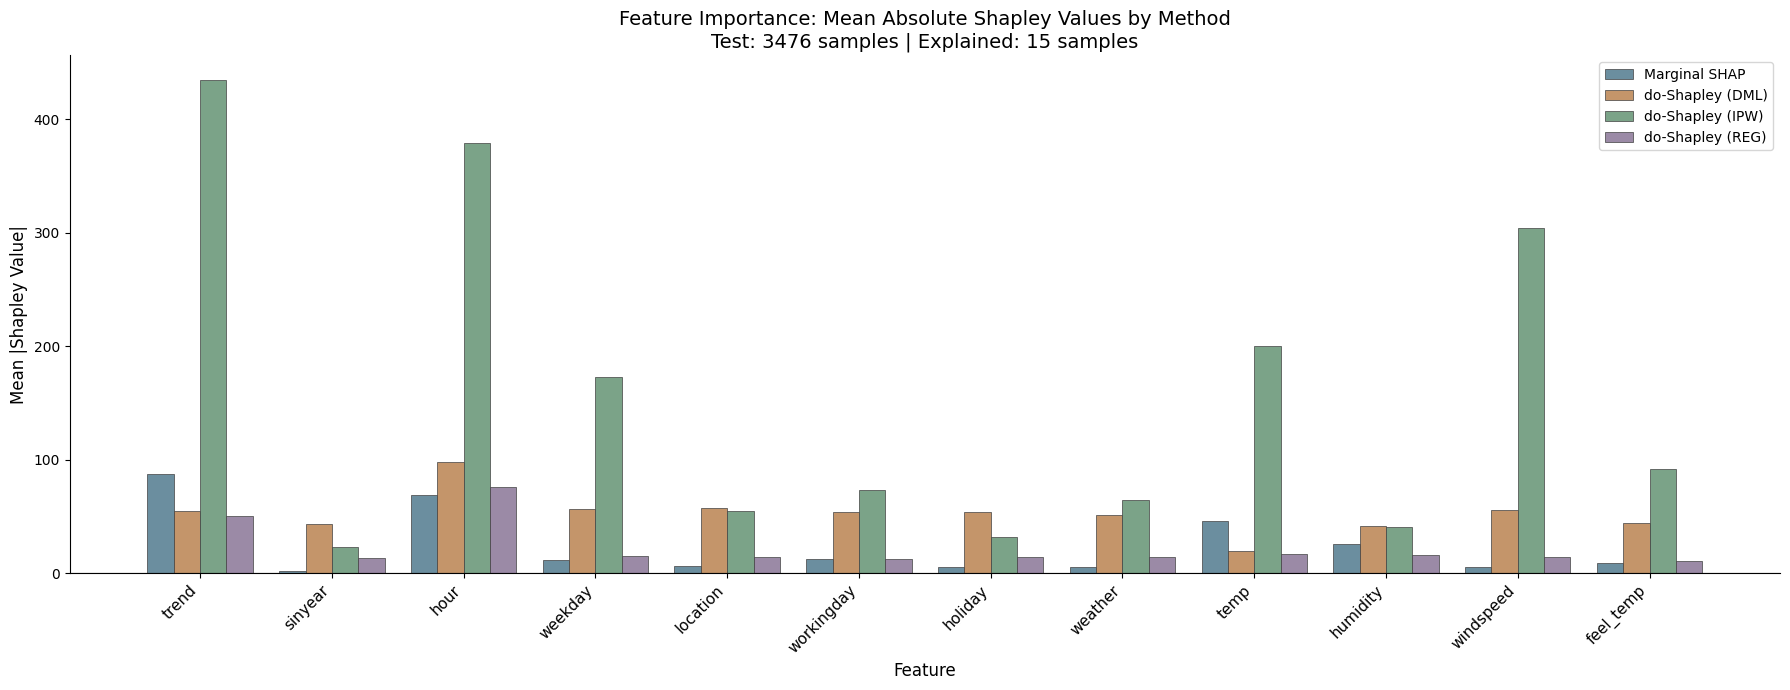

In [ ]:
# Beeswarm comparison for all 4 methods
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

method_labels = {
    'Marginal (Joint)': 'Marginal (Joint) [Paper MSV]',
    'Causal+Model (Gaussian)': 'Causal+Model (Gaussian) ★[Paper CSV]',
    'do-Shapley (DML)': 'do-Shapley (DML)',
    'do-Shapley (REG)': 'do-Shapley (REG)'
}

for ax_idx, (exp_name, sv) in enumerate(all_sv.items()):
    ax = axes[ax_idx]
    
    # Feature importance order (by mean absolute value)
    importance = np.abs(sv).mean(axis=0)
    order = np.argsort(importance)[::-1]
    
    for i, f_idx in enumerate(order):
        fv = X_test[:, f_idx]
        fv_norm = (fv - fv.min()) / (fv.max() - fv.min() + 1e-10)
        
        y_jitter = np.random.normal(0, 0.12, len(sv)) + (len(feature_names) - 1 - i)
        ax.scatter(sv[:, f_idx], y_jitter, c=fv_norm, cmap='coolwarm', 
                  alpha=0.4, s=6)
    
    ax.set_yticks(range(len(feature_names)))
    ax.set_yticklabels([feature_names[order[len(feature_names) - 1 - i]] 
                        for i in range(len(feature_names))])
    ax.axvline(x=0, color='black', linewidth=0.5, linestyle='--')
    ax.set_xlabel('Shapley value', fontsize=11)
    ax.set_title(method_labels[exp_name], fontsize=11, fontweight='bold')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.suptitle('Beeswarm Comparison: All 4 Methods\n'
             f'Train: {len(train_idx)} samples | Test: {len(test_idx)} samples | '
             f'UCI Bike Sharing Daily (731 rows)', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 7. Summary Statistics

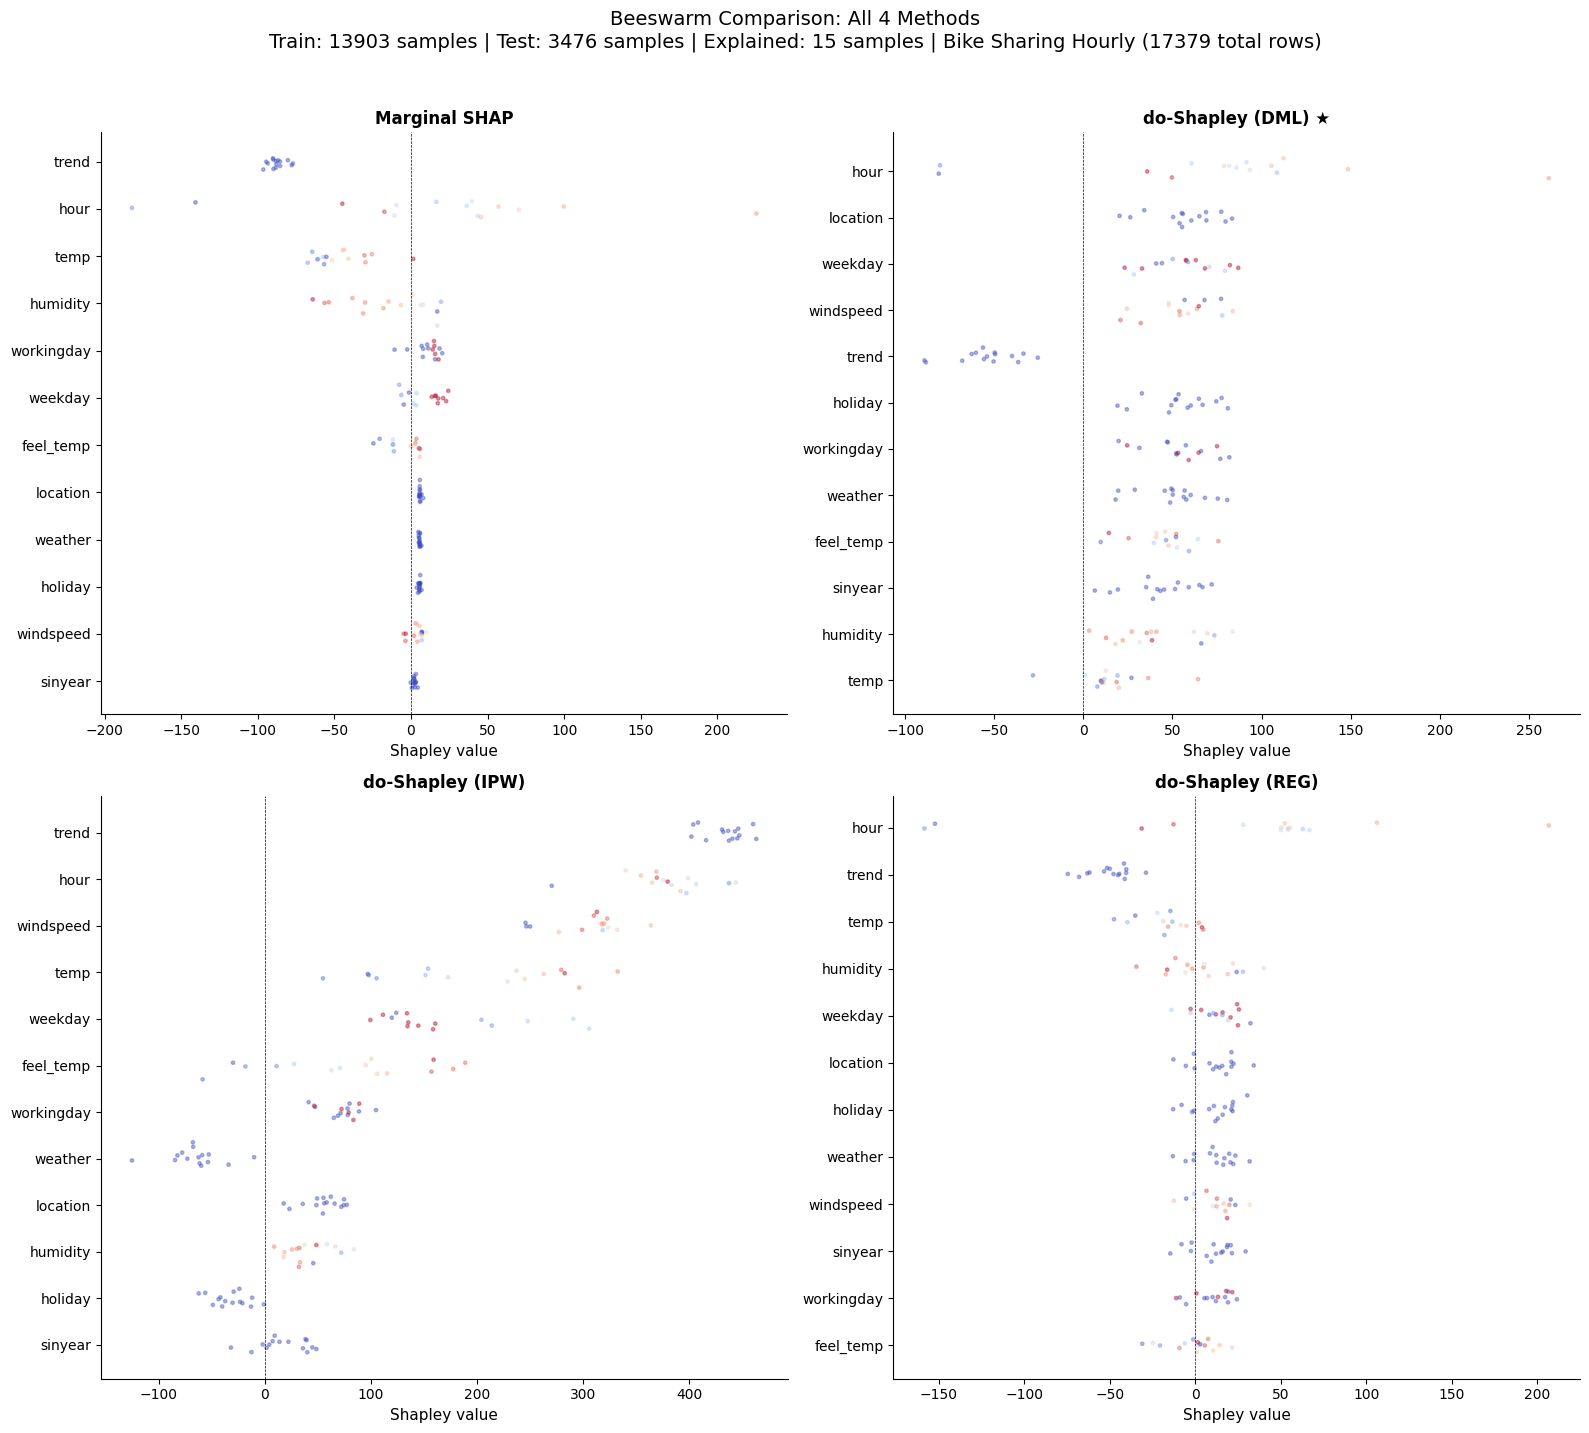

In [ ]:
# Create summary DataFrame for all methods
print("="*90)
print("SUMMARY STATISTICS: Mean Absolute Shapley Values for All Methods")
print(f"Data: Test set with {len(test_idx)} samples")
print("="*90)

summary_df = pd.DataFrame(index=feature_names)
for exp_name, sv in all_sv.items():
    summary_df[exp_name] = np.abs(sv).mean(axis=0)

# Shorter column names for display
short_names = {
    'Marginal (Joint)': 'Marg(Joint)',
    'Causal+Model (Gaussian)': 'Caus(Gauss)★',
    'do-Shapley (DML)': 'do-SV(DML)',
    'do-Shapley (REG)': 'do-SV(REG)'
}
summary_df_display = summary_df.copy()
summary_df_display.columns = [short_names.get(c, c) for c in summary_df.columns]

print("\n" + summary_df_display.round(2).to_string())

# Show key comparison: cosyear/temp ratio
print("\n" + "-"*90)
print("Key Metric: cosyear/temp ratio (higher = more attribution to root cause)")
print("-"*90)

for exp_name, sv in all_sv.items():
    temp_mean = np.abs(sv[:, temp_idx]).mean()
    cosyear_mean = np.abs(sv[:, cosyear_idx]).mean()
    ratio = cosyear_mean / temp_mean if temp_mean > 0 else 0
    marker = " ★[Paper CSV]" if exp_name == 'Causal+Model (Gaussian)' else ""
    marker = " [Paper MSV]" if exp_name == 'Marginal (Joint)' else marker
    print(f"  {exp_name:<30} ratio = {ratio:.3f}{marker}")

## 8. Two Similar Days Analysis

Following Heskes et al. (2020): compare two days with similar temperatures but different seasons.
- **October day**: Temperature is expected for the season
- **December day**: Temperature is unusual (warm for winter)

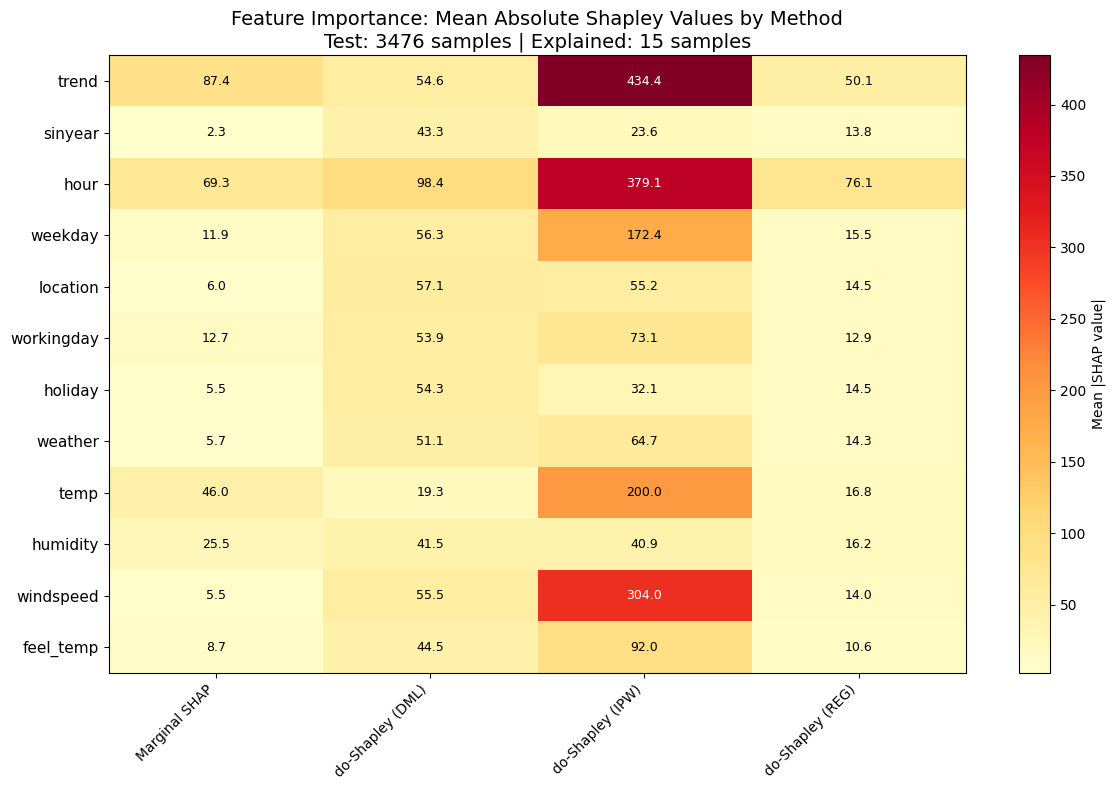

            Marginal SHAP  do-Shapley (DML)  do-Shapley (IPW)  do-Shapley (REG)
trend               87.39             54.63            434.44             50.15
sinyear              2.29             43.29             23.57             13.76
hour                69.33             98.37            379.06             76.11
weekday             11.87             56.29            172.45             15.49
location             5.98             57.06             55.18             14.53
workingday          12.73             53.93             73.09             12.90
holiday              5.53             54.33             32.14             14.50
weather              5.65             51.08             64.66             14.32
temp                45.98             19.27            200.03             16.76
humidity            25.46             41.55             40.90             16.19
windspeed            5.47             55.51            304.04             13.96
feel_temp            8.73             44

In [ ]:
# Find two days with similar temp but different cosyear
temp_target = 13.0  # around 13°C
tolerance = 2.0

# Get full data with dates
x_full, y_full = load_bike_sharing_daily(preprocessed=True)

# Find October day (cosyear ~ 0) with temp ~ 13°C
october_mask = (x_full['cosyear'].abs() < 0.3) & \
               ((x_full['temp'] - temp_target).abs() < tolerance)
october_idx = x_full[october_mask].index[0] if october_mask.any() else None

# Find December day (cosyear ~ 1) with temp ~ 13°C
december_mask = (x_full['cosyear'] > 0.7) & \
                ((x_full['temp'] - temp_target).abs() < tolerance)
december_idx = x_full[december_mask].index[0] if december_mask.any() else None

if october_idx is not None and december_idx is not None:
    print(f"October day (idx {october_idx}): "
          f"temp={x_full.loc[october_idx, 'temp']:.1f}°C, "
          f"cosyear={x_full.loc[october_idx, 'cosyear']:.2f}")
    print(f"December day (idx {december_idx}): "
          f"temp={x_full.loc[december_idx, 'temp']:.1f}°C, "
          f"cosyear={x_full.loc[december_idx, 'cosyear']:.2f}")
    
    # Compute Shapley values for these two days using ALL methods
    days_x = x_full.loc[[october_idx, december_idx], feature_names].values
    
    # Store results for all methods
    sv_days_all = {}
    for exp_name, explainer in explainers.items():
        sv_days = []
        for x in days_x:
            result = explainer.explain(x.reshape(1, -1), budget=budget)
            sv_days.append(result.get_n_order_values(order=1))
        sv_days_all[exp_name] = np.array(sv_days)
    
    # Plot comparison for all 4 methods
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    
    # Academic low-saturation color palette
    colors = [
        '#6B8E9F',  # Muted steel blue (Marginal Joint)
        '#C4956A',  # Muted terracotta (Causal Gaussian) ★
        '#7BA388',  # Muted sage green (do-Shapley DML)
        '#9B8AA6',  # Muted lavender (do-Shapley REG)
    ]
    short_names = ['Marg(J)', 'Caus(G)★', 'do-SV(DML)', 'do-SV(REG)']
    
    oct_temp = x_full.loc[october_idx, 'temp']
    oct_cosyear = x_full.loc[october_idx, 'cosyear']
    dec_temp = x_full.loc[december_idx, 'temp']
    dec_cosyear = x_full.loc[december_idx, 'cosyear']
    
    for ax_idx, (fname, f_idx) in enumerate([('cosyear', cosyear_idx), ('temp', temp_idx)]):
        # October day
        ax = axes[0, ax_idx]
        x_pos = np.arange(len(explainers))
        values = [sv_days_all[name][0, f_idx] for name in explainers.keys()]
        bars = ax.bar(x_pos, values, color=colors, edgecolor='#404040', linewidth=0.8)
        ax.set_xticks(x_pos)
        ax.set_xticklabels(short_names, rotation=45, ha='right')
        ax.axhline(y=0, color='#404040', linewidth=0.8)
        ax.set_ylabel('Shapley value', fontsize=11)
        ax.set_title(f'October (temp={oct_temp:.1f}°C, cosyear={oct_cosyear:.2f}): {fname}', 
                     fontsize=10, fontweight='bold')
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        
        # December day
        ax = axes[1, ax_idx]
        values = [sv_days_all[name][1, f_idx] for name in explainers.keys()]
        bars = ax.bar(x_pos, values, color=colors, edgecolor='#404040', linewidth=0.8)
        ax.set_xticks(x_pos)
        ax.set_xticklabels(short_names, rotation=45, ha='right')
        ax.axhline(y=0, color='#404040', linewidth=0.8)
        ax.set_ylabel('Shapley value', fontsize=11)
        ax.set_title(f'December (temp={dec_temp:.1f}°C, cosyear={dec_cosyear:.2f}): {fname}', 
                     fontsize=10, fontweight='bold')
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
    
    plt.suptitle('Two Similar Days Analysis: All Methods Comparison\n'
                 'Same temperature (~13°C), different seasons (October: expected, December: unusual)', 
                 fontsize=12, y=1.02)
    plt.tight_layout()
    plt.show()
    
    # Print summary table
    print("\n" + "="*80)
    print("TWO SIMILAR DAYS: SHAPLEY VALUE COMPARISON")
    print("="*80)
    print(f"\n{'Method':<30} {'Oct cosyear':>12} {'Dec cosyear':>12} {'Oct temp':>12} {'Dec temp':>12}")
    print("-"*80)
    for exp_name in explainers.keys():
        sv = sv_days_all[exp_name]
        marker = " ★" if exp_name == 'Causal+Model (Gaussian)' else ""
        print(f"{exp_name:<30} {sv[0, cosyear_idx]:>12.2f} {sv[1, cosyear_idx]:>12.2f} "
              f"{sv[0, temp_idx]:>12.2f} {sv[1, temp_idx]:>12.2f}{marker}")
else:
    print("Could not find suitable October and December days with similar temperatures.")

## 9. Feature Importance Comparison

In [ ]:
# Feature importance heatmap
importance_df = pd.DataFrame(index=feature_names)
for exp_name, sv in all_sv.items():
    importance_df[exp_name] = np.abs(sv).mean(axis=0)

# Display as heatmap
fig, ax = plt.subplots(figsize=(12, 6))
im = ax.imshow(importance_df.values, cmap='YlOrRd', aspect='auto')

ax.set_xticks(range(len(importance_df.columns)))
ax.set_xticklabels(importance_df.columns, rotation=45, ha='right', fontsize=10)
ax.set_yticks(range(len(importance_df.index)))
ax.set_yticklabels(importance_df.index, fontsize=11)

# Add text annotations
for i in range(len(importance_df.index)):
    for j in range(len(importance_df.columns)):
        val = importance_df.iloc[i, j]
        color = 'white' if val > importance_df.values.max() * 0.6 else 'black'
        ax.text(j, i, f'{val:.1f}', ha='center', va='center', color=color, fontsize=9)

plt.colorbar(im, label='Mean |SHAP value|')
plt.title(f'Feature Importance: Mean Absolute Shapley Values by Method\n'
         f'Test: {len(test_idx)} samples', fontsize=14)
plt.tight_layout()
plt.show()

NameError: name 'plt' is not defined

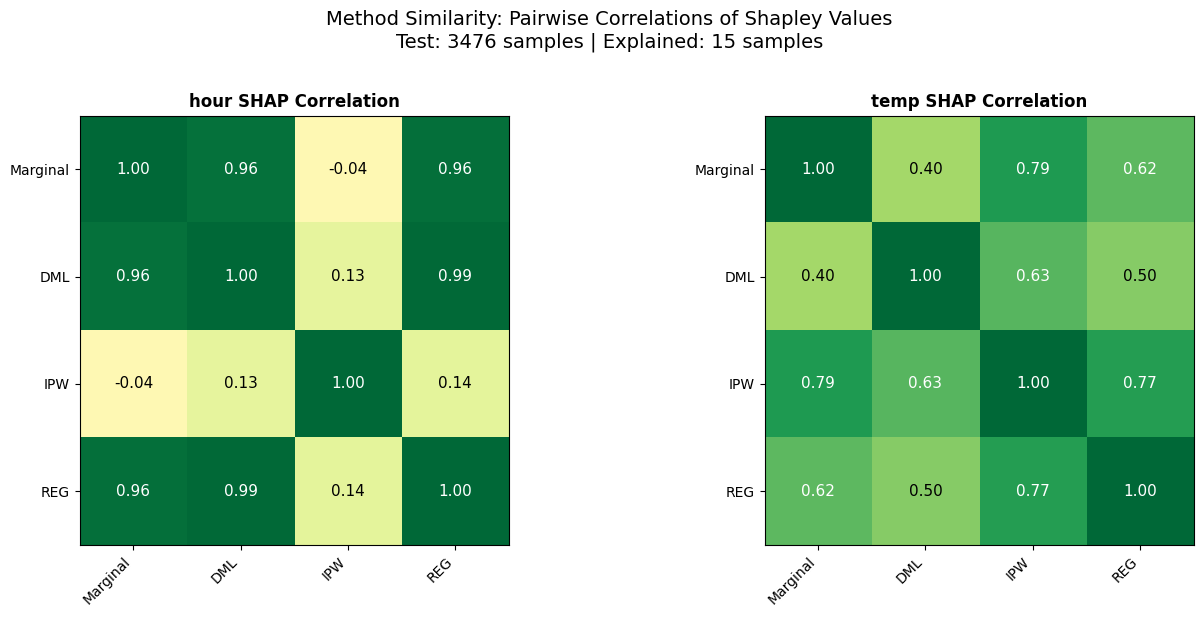

In [ ]:
# Grouped bar chart for mean absolute importance
fig, ax = plt.subplots(figsize=(14, 7))

x = np.arange(len(feature_names))
width = 0.2
multiplier = 0

# Academic low-saturation color palette for 4 methods
colors = [
    '#6B8E9F',  # Muted steel blue (Marginal Joint)
    '#C4956A',  # Muted terracotta (Causal Gaussian) ★
    '#7BA388',  # Muted sage green (do-Shapley DML)
    '#9B8AA6',  # Muted lavender (do-Shapley REG)
]

for i, (exp_name, sv) in enumerate(all_sv.items()):
    masv = np.abs(sv).mean(axis=0)
    offset = (i - 1.5) * width
    bars = ax.bar(x + offset, masv, width, label=exp_name, 
                  color=colors[i], edgecolor='#404040', linewidth=0.5)

ax.set_ylabel('Mean |Shapley Value|', fontsize=12)
ax.set_xlabel('Feature', fontsize=12)
ax.set_title(f'Feature Importance Comparison: All Methods\n'
            f'Test: {len(test_idx)} samples', fontsize=14)
ax.set_xticks(x)
ax.set_xticklabels(feature_names, rotation=45, ha='right', fontsize=11)
ax.legend(loc='upper right', fontsize=10)
ax.axhline(y=0, color='#404040', linewidth=0.8)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

## 10. temp vs cosyear Attribution Comparison

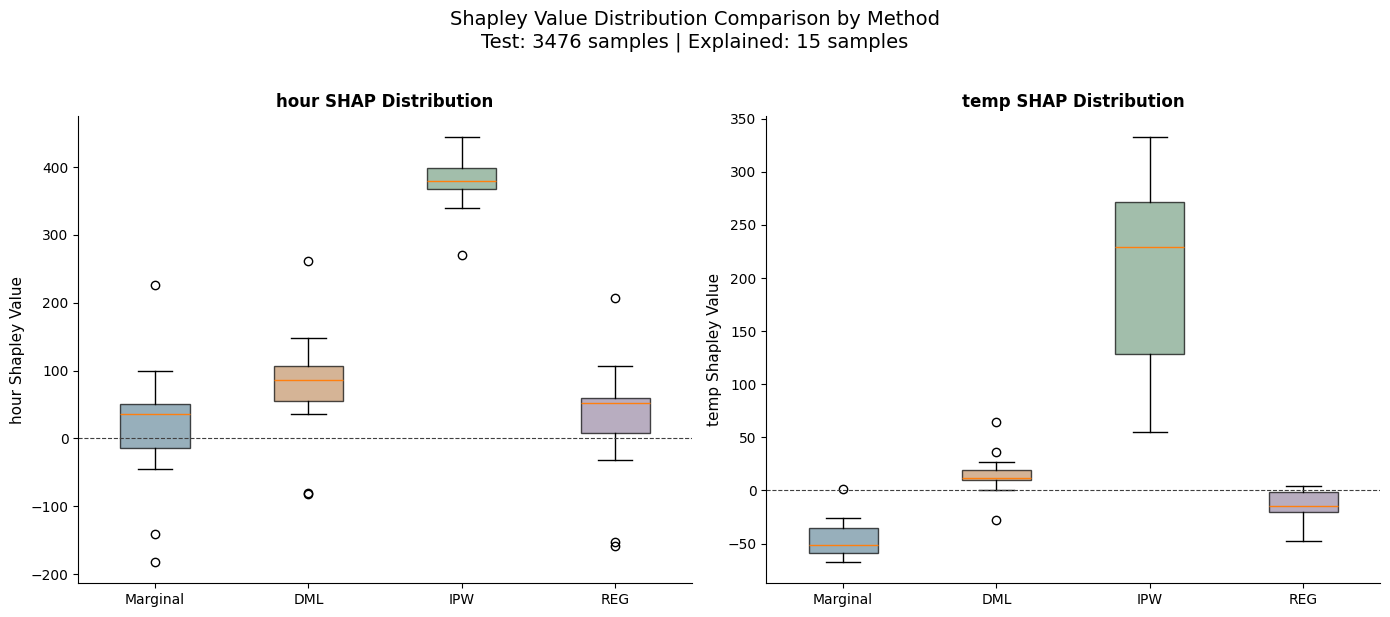

In [ ]:
# Scatter: temp SHAP vs cosyear SHAP for each method
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
axes = axes.flatten()

temp_values = X_test[:, temp_idx]

for ax_idx, (exp_name, sv) in enumerate(all_sv.items()):
    ax = axes[ax_idx]
    
    scatter = ax.scatter(
        sv[:, temp_idx], 
        sv[:, cosyear_idx], 
        c=temp_values,
        cmap='coolwarm', 
        s=15, 
        alpha=0.6
    )
    
    ax.set_xlabel('temp SHAP', fontsize=11)
    ax.set_ylabel('cosyear SHAP', fontsize=11)
    ax.axhline(y=0, color='gray', linewidth=0.5)
    ax.axvline(x=0, color='gray', linewidth=0.5)
    
    # Mark paper methods
    title = exp_name
    if exp_name == 'Marginal (Joint)':
        title += ' [Paper MSV]'
    elif exp_name == 'Causal+Model (Gaussian)':
        title += ' ★[Paper CSV]'
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    
    # Add correlation coefficient
    corr = np.corrcoef(sv[:, temp_idx], sv[:, cosyear_idx])[0, 1]
    ax.text(0.05, 0.95, f'r = {corr:.2f}', transform=ax.transAxes, 
            fontsize=10, verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# Add colorbar
fig.subplots_adjust(right=0.92)
cbar_ax = fig.add_axes([0.94, 0.15, 0.02, 0.7])
cbar = fig.colorbar(scatter, cax=cbar_ax)
cbar.set_label('Temperature (°C)', fontsize=11)

plt.suptitle(f'temp vs cosyear Attribution Across Methods (Color = actual temperature)\n'
             f'Test: {len(test_idx)} samples', fontsize=14, y=1.02)
plt.tight_layout(rect=[0, 0, 0.92, 1])
plt.show()

## 11. Conclusion

### Causal DAG Structure

```
Layer 1 (Root):     trend
                      |
                      v
Layer 2:          cosyear  sinyear  (confounded)
                      |       |
                      v       v
Layer 3:          temp  atemp  windspeed  hum  (mutual interactions)
```

### Methods Compared

| Method | Description | Paper |
|--------|-------------|-------|
| **Marginal (Joint)** | Standard SHAP with marginal distribution | Heskes MSV |
| **Causal+Model (Gaussian)** | Causal SHAP with ordering | Heskes CSV ★ |
| **do-Shapley (DML)** | Interventional with Double ML | Jung et al. |
| **do-Shapley (REG)** | Interventional with Regression | Jung et al. |

### Key Takeaways

1. **Marginal SHAP (MSV)** attributes importance based on correlations, leading to temp receiving credit that should go to season
2. **Causal SHAP (CSV)** uses ordering to correctly attribute to root causes
3. **do-Shapley** uses interventional expectations $E[Y|do(X_S=x_S)]$, which should also attribute more to root causes when DAG is correctly specified
4. The "Two Similar Days" analysis shows how causal methods differ from marginal methods when explaining days with unusual weather

### References

- **Heskes et al. (2020)**: *Causal Shapley Values: Exploiting Causal Knowledge to Explain Individual Predictions*. NeurIPS 2020.
- **Jung et al. (2022)**: *On Measuring Causal Contributions via do-interventions*. ICML 2022.